importing libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
from sklearn.model_selection import train_test_split
import math

Loading the dataset

In [4]:
train_df = pd.read_csv("Datast/train.csv")
test_df = pd.read_csv("Datast/test.csv")
building_df = pd.read_csv("Datast/building_metadata.csv")
weather_train_df = pd.read_csv("Datast/weather_train.csv")
weather_test_df = pd.read_csv("Datast/weather_test.csv")

In [5]:
weather_train_df.columns

Index(['site_id', 'timestamp', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed'],
      dtype='object')

Starting with weather dataset

In [6]:
weat_cop=weather_train_df.copy()

In [7]:
weat_cop.describe()

,site_id,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
count,139773.000000,139718.000000,70600.000000,139660.000000,89484.000000,129155.000000,133505.000000,139469.000000
mean,7.478977,14.418106,2.149306,7.350158,0.983047,1016.158038,180.526632,3.560527
std,4.604744,10.626595,2.599150,9.790235,8.463678,7.629684,111.523629,2.335874
min,0.000000,-28.900000,0.000000,-35.000000,-1.000000,968.200000,0.000000,0.000000
25%,3.000000,7.200000,0.000000,0.600000,0.000000,1011.800000,80.000000,2.100000
50%,7.000000,15.000000,2.000000,8.300000,0.000000,1016.400000,190.000000,3.100000
75%,11.000000,22.200000,4.000000,14.400000,0.000000,1020.800000,280.000000,5.000000
max,15.000000,47.200000,9.000000,26.100000,343.000000,1045.500000,360.000000,19.000000


array([[<Axes: title={'center': 'site_id'}>,
        <Axes: title={'center': 'air_temperature'}>,
        <Axes: title={'center': 'cloud_coverage'}>],
       [<Axes: title={'center': 'dew_temperature'}>,
        <Axes: title={'center': 'precip_depth_1_hr'}>,
        <Axes: title={'center': 'sea_level_pressure'}>],
       [<Axes: title={'center': 'wind_direction'}>,
        <Axes: title={'center': 'wind_speed'}>, <Axes: >]], dtype=object)

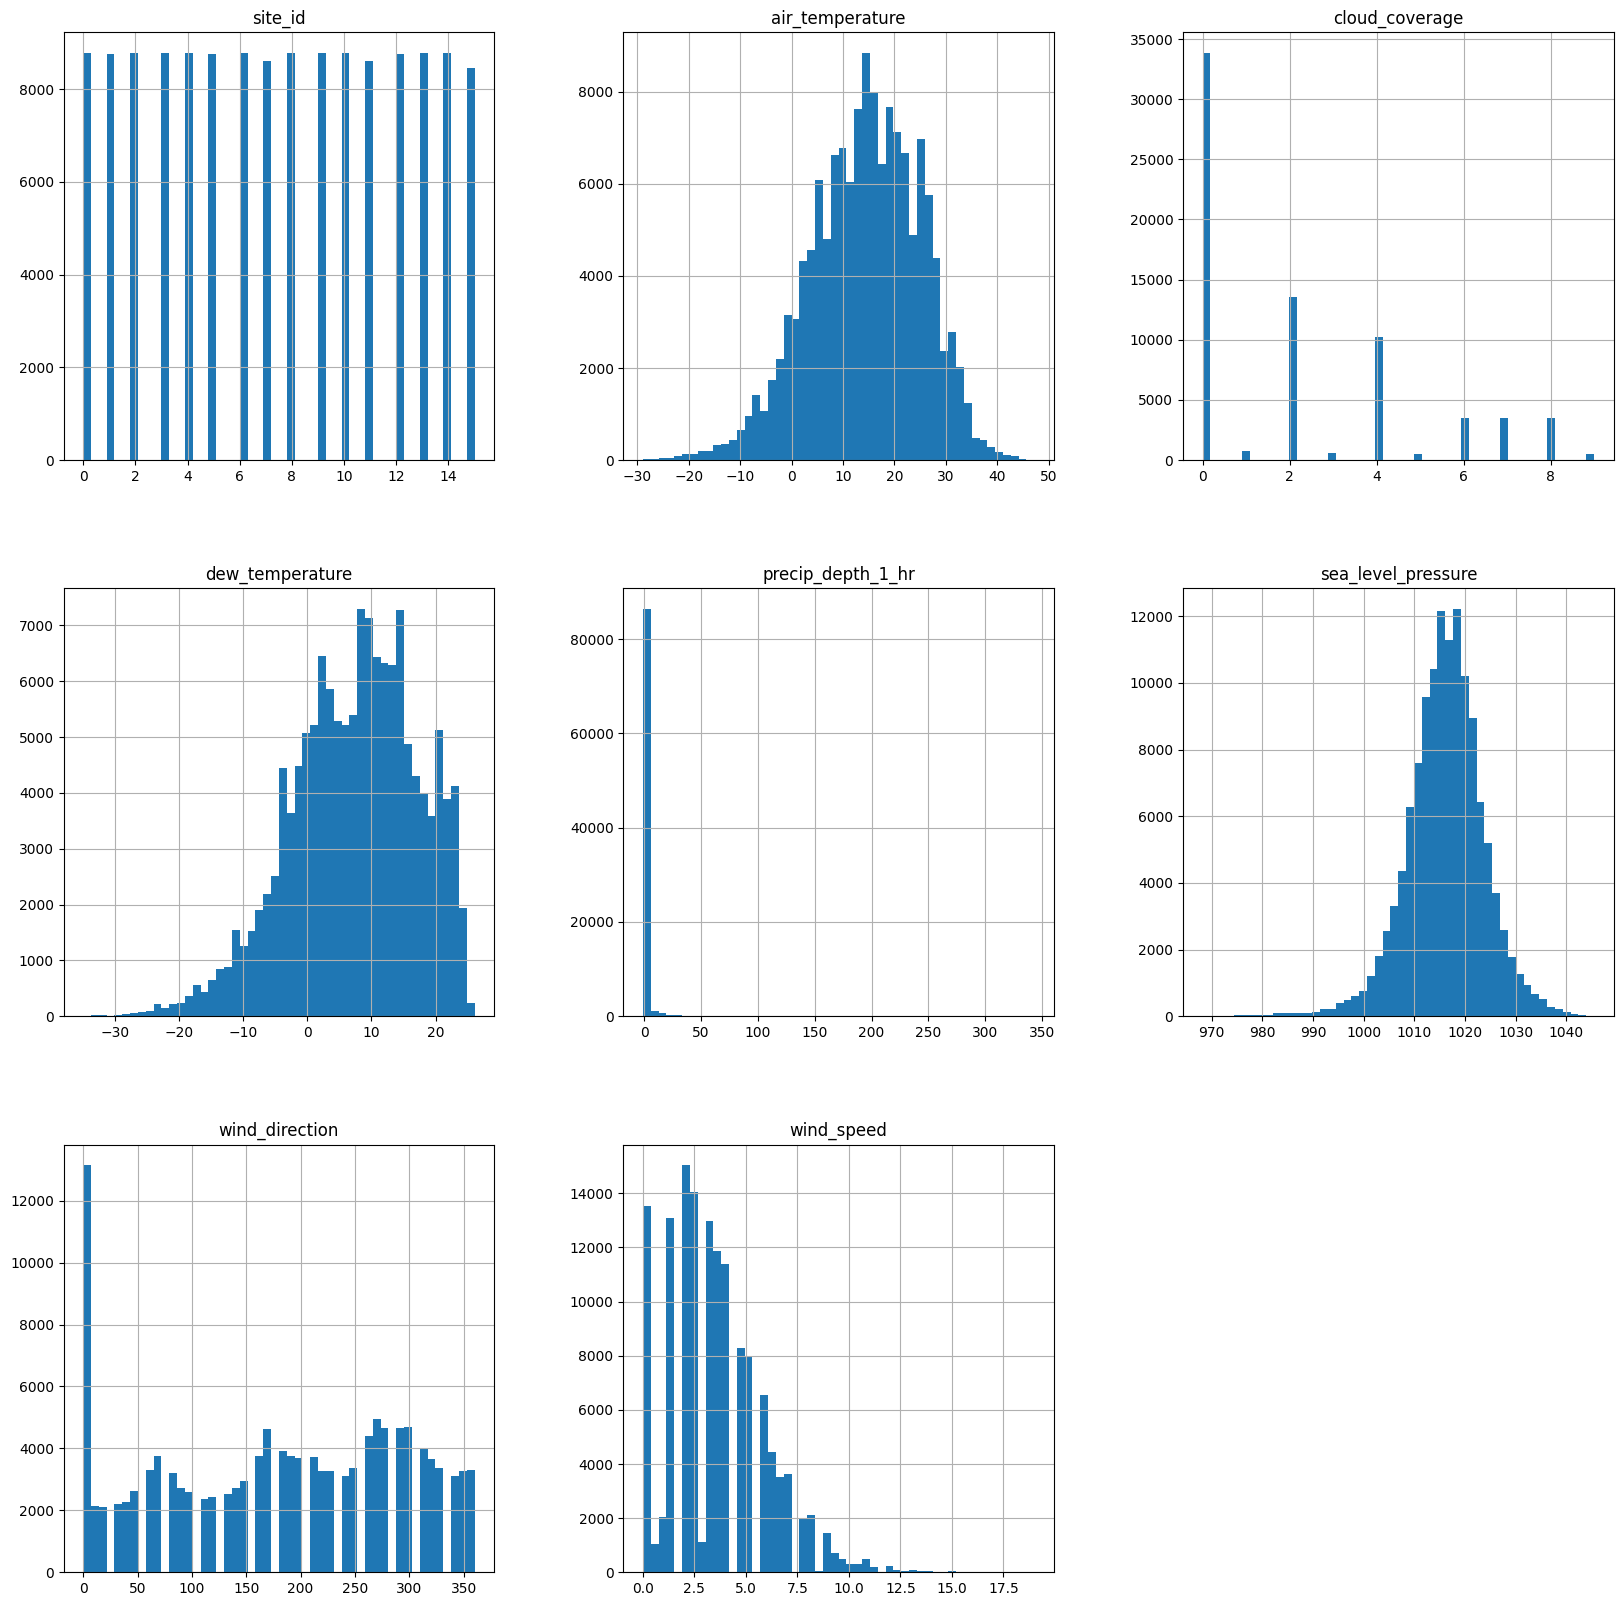

In [8]:
weat_cop.hist(bins=50,figsize=(20,20))

Adding feels like and relative humidity

In [9]:
def saturation_vapor_pressure(temperature):
    return 6.112 * math.exp((17.67 * temperature) / (temperature + 243.5))

# Function to calculate relative humidity
def relative_humidity(air_temp, dew_temp):
    E_air = saturation_vapor_pressure(air_temp)
    E_dew = saturation_vapor_pressure(dew_temp)
    RH = (E_dew / E_air) * 100
    return RH

# Apply the function to each row in the dataframe to calculate relative humidity
weat_cop['relative_humidity'] = weat_cop.apply(lambda row: relative_humidity(row['air_temperature'], row['dew_temperature']), axis=1)
# test_wet_cop['relative_humidity'] = test_wet_cop.apply(lambda row: relative_humidity(row['air_temperature'], row['dew_temperature']), axis=1)

In [10]:
# Simplified heat index (Rothfusz regression approximation)
weat_cop['heat_index'] = (
    0.5 * (weat_cop['air_temperature'] + 61.0 + 
    (weat_cop['air_temperature'] - 68.0) * 1.2 + 
    weat_cop['dew_temperature'] * 0.094
)
)

# Wind chill (for temps < 10°C and wind > 4.8 km/h)
mask = (weat_cop['air_temperature'] < 10) & (weat_cop['wind_speed'] > 1.34)  # 1.34 m/s ≈ 4.8 km/h
weat_cop['wind_chill'] = (
    13.12 + 0.6215 * weat_cop['air_temperature'] - 
    11.37 * (weat_cop['wind_speed'] ** 0.16) + 
    0.3965 * weat_cop['air_temperature'] * (weat_cop['wind_speed'] ** 0.16)
)
weat_cop['wind_chill'] = weat_cop['wind_chill'].where(mask, weat_cop['air_temperature'])

weat_cop['feels_like'] = np.where(
    weat_cop['air_temperature'] >= 27,  # Hot threshold
    weat_cop['heat_index'],
    np.where(
        weat_cop['air_temperature'] <= 10,  # Cold threshold
        weat_cop['wind_chill'],
        weat_cop['air_temperature']  # Default
    )
)

Convertinig timestamp to hour,day,month,day of year, weekend, season, and cyclic encoding for hour,day,month

In [11]:
import numpy as np
import pandas as pd

# Assuming weat_cop is your weather dataframe
weat_cop["timestamp"] = pd.to_datetime(weat_cop["timestamp"])

# Extract basic time features
weat_cop["hour"] = weat_cop["timestamp"].dt.hour
weat_cop["day_of_week"] = weat_cop["timestamp"].dt.weekday  # Monday=0, Sunday=6
weat_cop["month"] = weat_cop["timestamp"].dt.month
weat_cop["day_of_year"] = weat_cop["timestamp"].dt.dayofyear
weat_cop["is_weekend"] = (weat_cop["day_of_week"] >= 5).astype(int)

# Cyclical encoding for hour
weat_cop["hour_sin"] = np.sin(2 * np.pi * weat_cop["hour"] / 24)
weat_cop["hour_cos"] = np.cos(2 * np.pi * weat_cop["hour"] / 24)

# Cyclical encoding for day of the week
weat_cop["day_sin"] = np.sin(2 * np.pi * weat_cop["day_of_week"] / 7)
weat_cop["day_cos"] = np.cos(2 * np.pi * weat_cop["day_of_week"] / 7)

# Cyclical encoding for month
weat_cop["month_sin"] = np.sin(2 * np.pi * weat_cop["month"] / 12)
weat_cop["month_cos"] = np.cos(2 * np.pi * weat_cop["month"] / 12)

# Season encoding (0: Winter, 1: Spring, 2: Summer, 3: Fall)
weat_cop["season"] = weat_cop["month"].map(lambda m: 0 if m in [12, 1, 2] else
                                         1 if m in [3, 4, 5] else
                                         2 if m in [6, 7, 8] else 3)

# Drop original timestamp column if no longer needed
# weat_cop.drop(columns=["timestamp"], inplace=True)

# Display updated dataframe
weat_cop.head()


,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,relative_humidity,...,month,day_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0,73.780558,...,1,1,0,0.000000,1.000000,-0.433884,-0.900969,0.5,0.866025,0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5,81.848292,...,1,1,0,0.258819,0.965926,-0.433884,-0.900969,0.5,0.866025,0
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0,90.139994,...,1,1,0,0.500000,0.866025,-0.433884,-0.900969,0.5,0.866025,0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0,96.968347,...,1,1,0,0.707107,0.707107,-0.433884,-0.900969,0.5,0.866025,0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6,100.000000,...,1,1,0,0.866025,0.500000,-0.433884,-0.900969,0.5,0.866025,0


Capping feels like at -10 low and 35 high as after this the load will always be at max

In [12]:
T_min = -10  # Below this, heating load is maxed
T_max = 35   # Above this, cooling load is maxed

weat_cop['feels_like_capped'] = weat_cop['feels_like'].clip(T_min, T_max)
weat_cop['feels_like_capped']

0         25.000000
1         24.400000
2         22.800000
3         21.100000
4         20.000000
            ...    
139768     1.534909
139769     0.637652
139770     1.544926
139771     1.086355
139772    -0.970798
Name: feels_like_capped, Length: 139773, dtype: float64

linear interpolating precipitation data to fill the -1 values with a 6 hour limit interpolation or 0 otherwise

In [ ]:

weat_cop['precip_depth_1_hr'] = (
    weat_cop['precip_depth_1_hr']
    .replace(-1.0, np.nan)
    .interpolate(method='linear', limit=6)  # 6-hour gap limit
    .fillna(0)  # Fill remaining gaps with 0
)


Adding bins for rain intensity based on precipitation data

In [14]:
bins = [-0.1, 0.1, 5.0, 15.0, float('inf')]  # -0.1 to catch near-zero values  
labels = ['No Rain', 'Light Rain', 'Moderate Rain', 'Heavy Rain']  

weat_cop['precip_1h_category'] = pd.cut(
    weat_cop['precip_depth_1_hr'],  
    bins=bins,  
    labels=labels  
)

In [15]:
weat_cop['is_light_rain'] = (weat_cop['precip_depth_1_hr'] > 0.1).astype(int)  

weat_cop['is_moderate_rain'] = ((weat_cop['precip_depth_1_hr'] > 5.0) & (weat_cop['precip_depth_1_hr'] < 15.0)).astype(int)

weat_cop['is_heavy_rain'] = (weat_cop['precip_depth_1_hr'] >= 15.0).astype(int)  

Winsorize sea level pressure to handle outliers

In [16]:
from scipy.stats.mstats import winsorize

weat_cop["sea_level_pressure"] = winsorize(weat_cop["sea_level_pressure"], limits=[0.01, 0.01])  # Capping at 0.5% on both ends  

In [17]:
selected_features = [
    "site_id","relative_humidity", "feels_like_capped", "wind_speed", "precip_1h_category", "is_light_rain", "is_moderate_rain", "is_heavy_rain", 
    'hour', 'day_of_week', 'month', 'day_of_year',
       'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'season','timestamp'
]

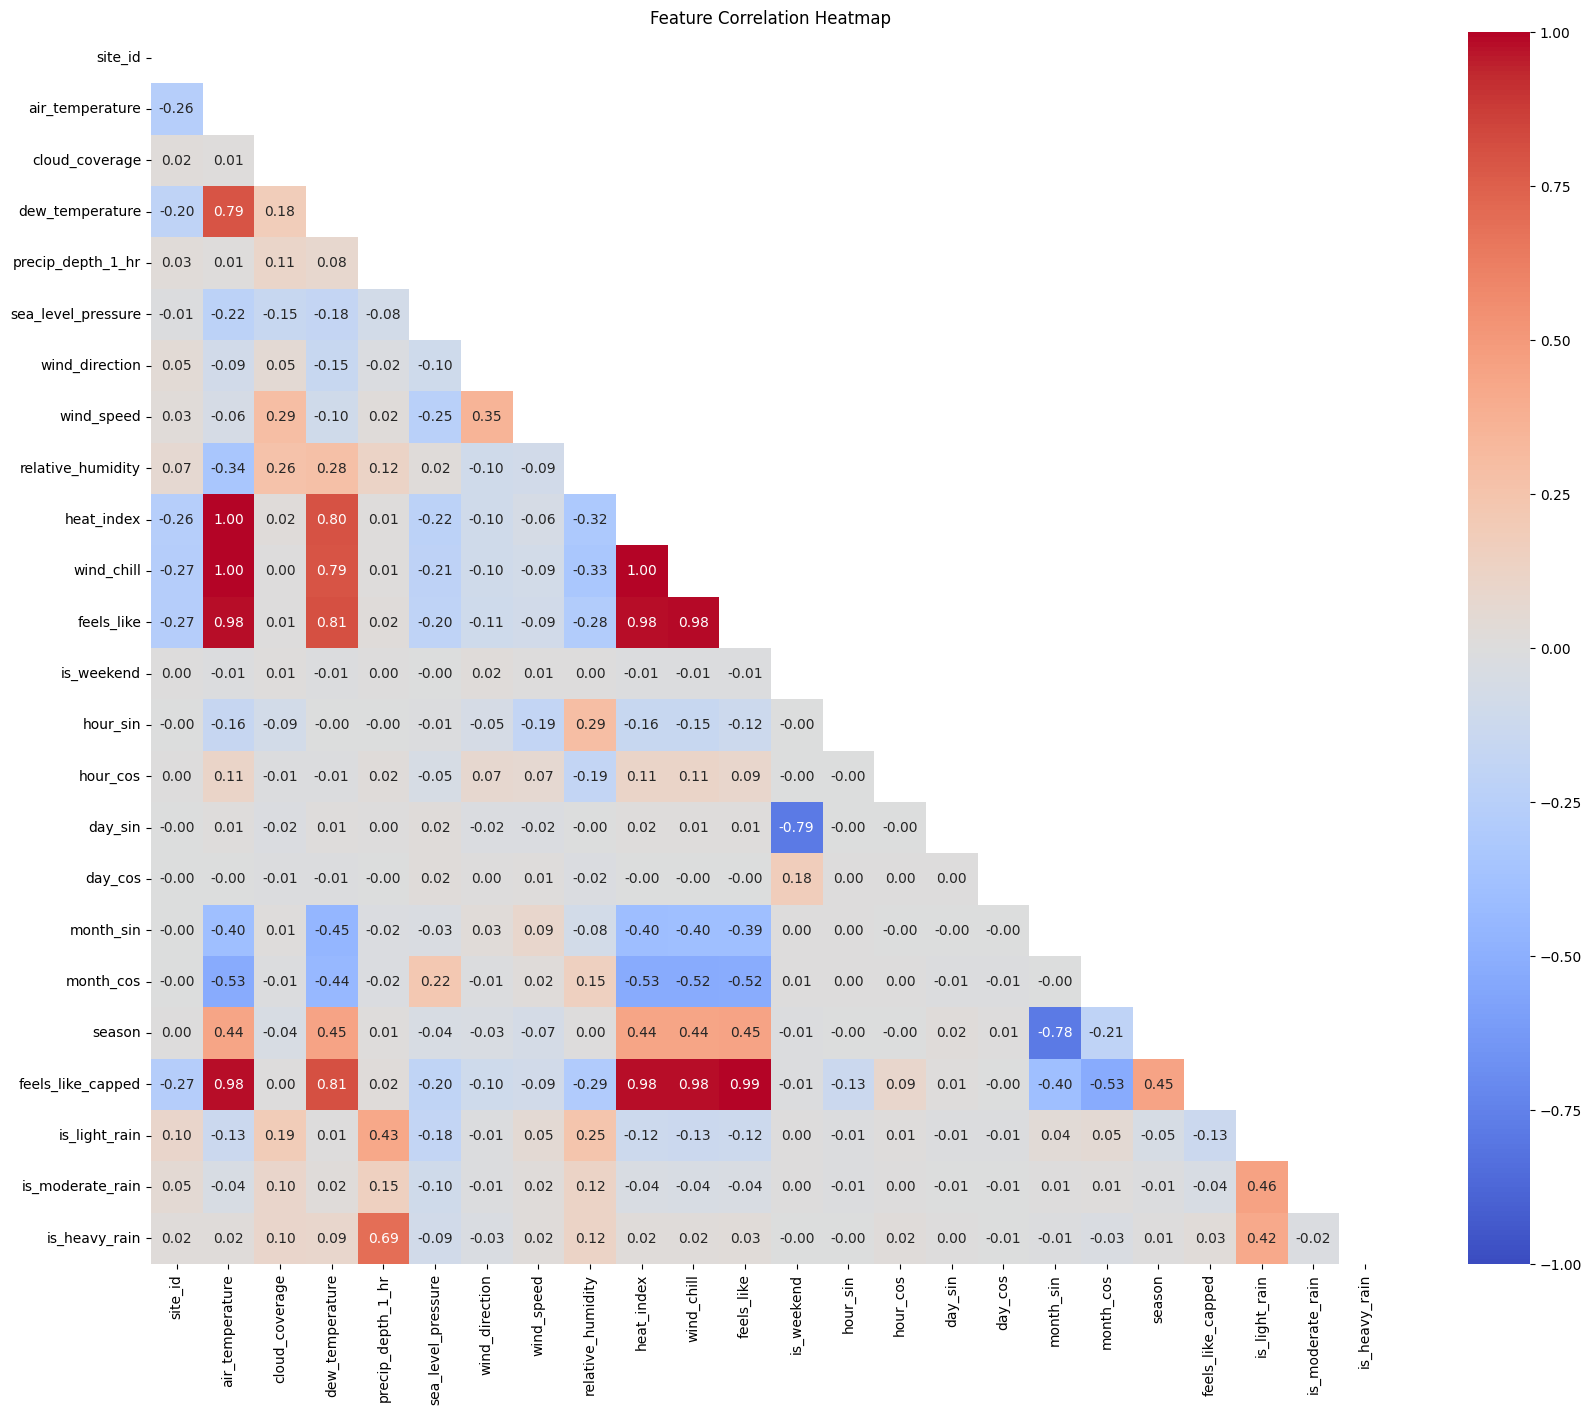

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = weat_cop.select_dtypes(include=['float64', 'int64']).columns
corr_df = weat_cop[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(corr_df))  # Hide upper triangle for clarity
)
plt.title("Feature Correlation Heatmap")
plt.show()

checking feels like against months

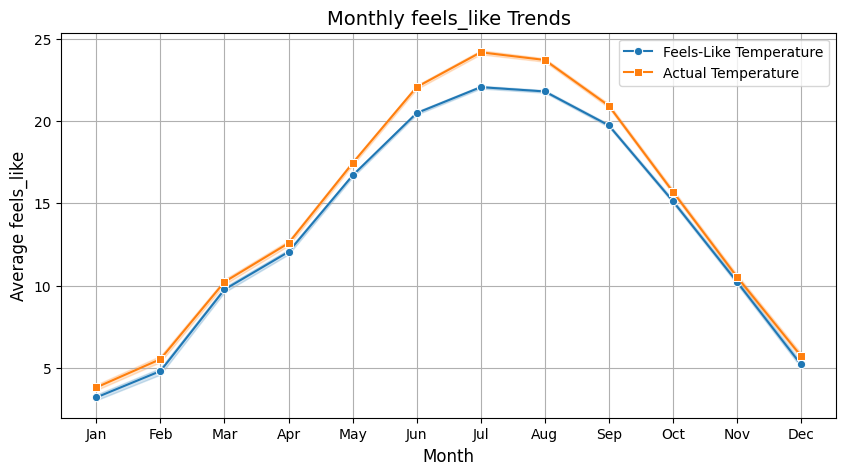

In [61]:
monthly_readings = weat_cop.groupby("month")["feels_like"].mean()

# Plot
plt.figure(figsize=(10, 5))
# sns.lineplot(x=monthly_readings.index, y=monthly_readings.values, marker="o", linestyle="-", color="b")
sns.lineplot(data=weat_cop, x='month', y='feels_like', label='Feels-Like Temperature', marker='o')
sns.lineplot(data=weat_cop, x='month', y='air_temperature', label='Actual Temperature', marker='s')

# Labels and title
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average feels_like", fontsize=12)
plt.title("Monthly feels_like Trends", fontsize=14)
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.grid(True)

# Show plot
plt.show()

In [62]:
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Convert timestamp to datetime & extract month
# weat_cop['timestamp'] = pd.to_datetime(weat_cop['timestamp'])
# weat_cop['month'] = weat_cop['timestamp'].dt.month

# # Plot monthly average Feels-Like vs. Air Temperature
# plt.figure(figsize=(10, 5))
# sns.lineplot(data=weat_cop, x='month', y='feels_like', label='Feels-Like Temperature', marker='o')
# sns.lineplot(data=weat_cop, x='month', y='air_temperature', label='Actual Temperature', marker='s')
# plt.xlabel('Month')
# plt.ylabel('Temperature (°C)')
# plt.title('Feels-Like vs. Actual Temperature (Monthly)')
# plt.legend()
# plt.grid()
# plt.show()


In [21]:
weat_cop.columns

Index(['site_id', 'timestamp', 'air_temperature', 'cloud_coverage',
       'dew_temperature', 'precip_depth_1_hr', 'sea_level_pressure',
       'wind_direction', 'wind_speed', 'relative_humidity', 'heat_index',
       'wind_chill', 'feels_like', 'hour', 'day_of_week', 'month',
       'day_of_year', 'is_weekend', 'hour_sin', 'hour_cos', 'day_sin',
       'day_cos', 'month_sin', 'month_cos', 'season', 'feels_like_capped',
       'precip_1h_category', 'is_light_rain', 'is_moderate_rain',
       'is_heavy_rain'],
      dtype='object')

In [22]:
Final_weat=weat_cop[selected_features]

In [23]:
# Final_weat.isna().sum()

In [24]:
Final_weat[['feels_like_capped', 'relative_humidity', 'wind_speed']] = (
    Final_weat[['feels_like_capped', 'relative_humidity', 'wind_speed']].interpolate(method="linear")
)


C:\Users\zyzai\AppData\Local\Temp\ipykernel_3972\3843479888.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Final_weat[['feels_like_capped', 'relative_humidity', 'wind_speed']] = (


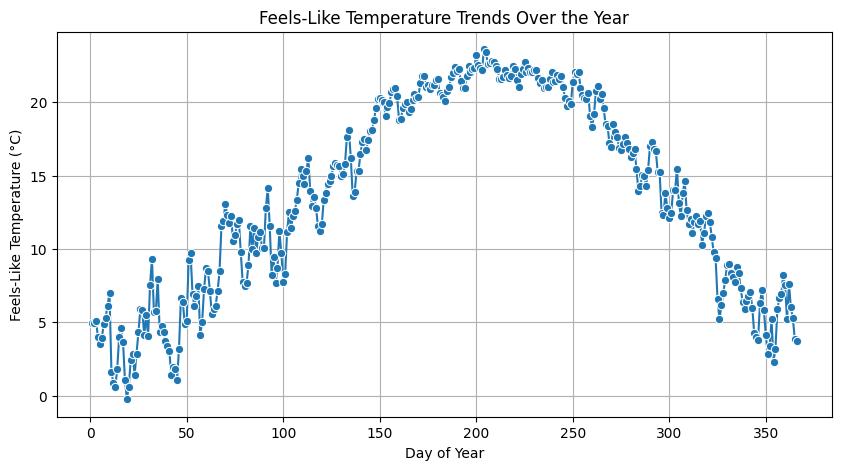

In [46]:
# Final_weat.columns

df_daily = Final_weat.groupby('day_of_year')['feels_like_capped'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_daily, x='day_of_year', y='feels_like_capped', marker='o')
plt.xlabel('Day of Year')
plt.ylabel('Feels-Like Temperature (°C)')
plt.title('Feels-Like Temperature Trends Over the Year')
plt.grid()
plt.show()


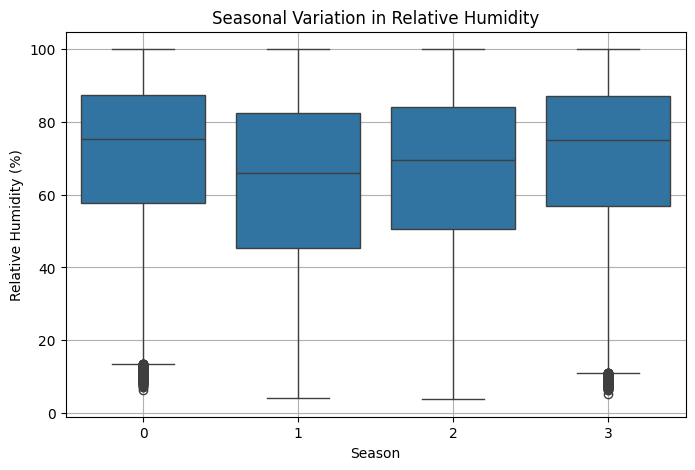

In [47]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=Final_weat, x='season', y='relative_humidity')
plt.xlabel('Season')
plt.ylabel('Relative Humidity (%)')
plt.title('Seasonal Variation in Relative Humidity')
plt.grid()
plt.show()


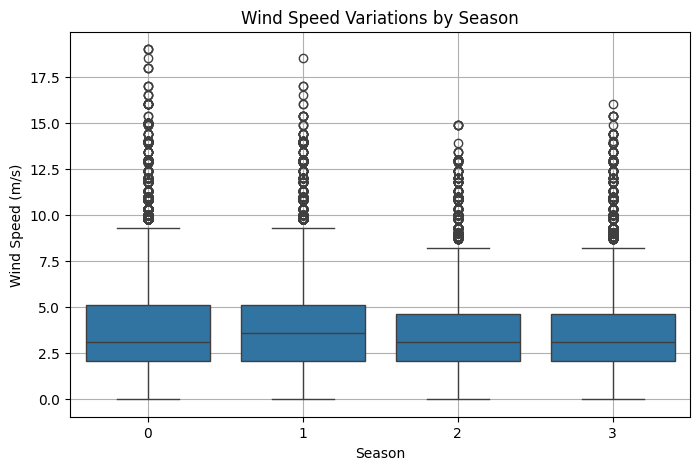

In [48]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=Final_weat, x='season', y='wind_speed')
plt.xlabel('Season')
plt.ylabel('Wind Speed (m/s)')
plt.title('Wind Speed Variations by Season')
plt.grid()
plt.show()


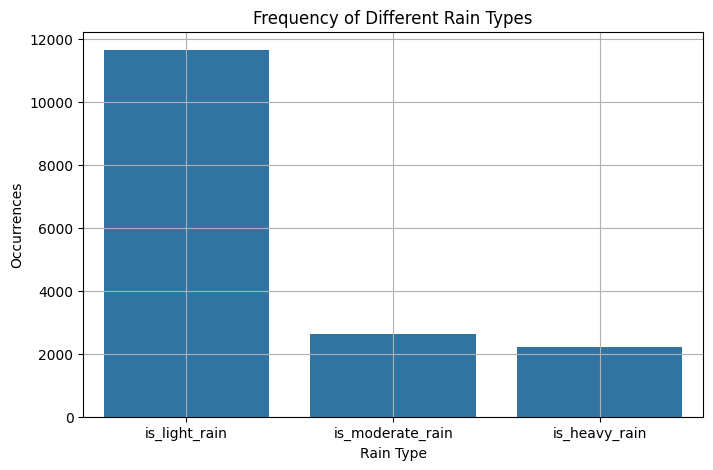

In [50]:
rain_counts = Final_weat[['is_light_rain', 'is_moderate_rain', 'is_heavy_rain']].sum()

plt.figure(figsize=(8, 5))
sns.barplot(x=rain_counts.index, y=rain_counts.values)
plt.xlabel('Rain Type')
plt.ylabel('Occurrences')
plt.title('Frequency of Different Rain Types')
plt.grid()
plt.show()


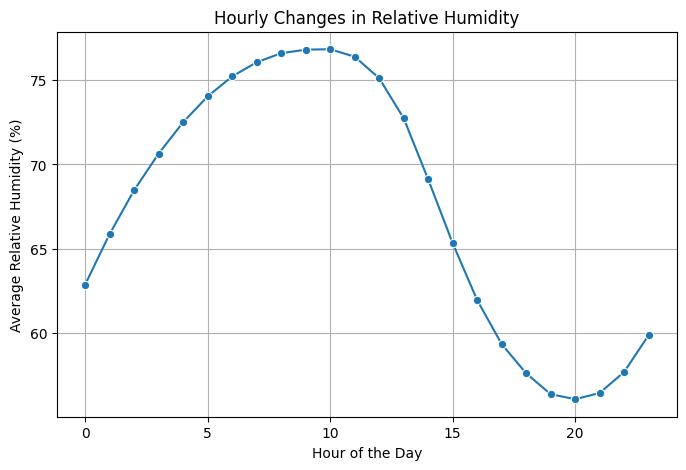

In [51]:
df_hourly = Final_weat.groupby('hour')['relative_humidity'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=df_hourly, x='hour', y='relative_humidity', marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Relative Humidity (%)')
plt.title('Hourly Changes in Relative Humidity')
plt.grid()
plt.show()


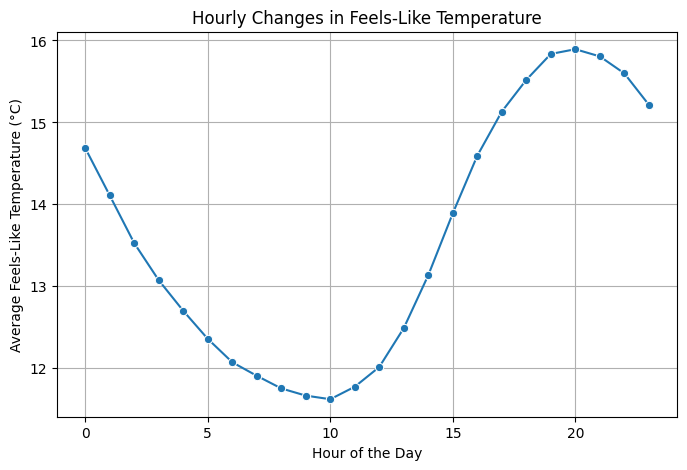

In [53]:

df_hourly = Final_weat.groupby('hour')['feels_like_capped'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=df_hourly, x='hour', y='feels_like_capped', marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Feels-Like Temperature (°C)')
plt.title('Hourly Changes in Feels-Like Temperature')
plt.grid()
plt.show()


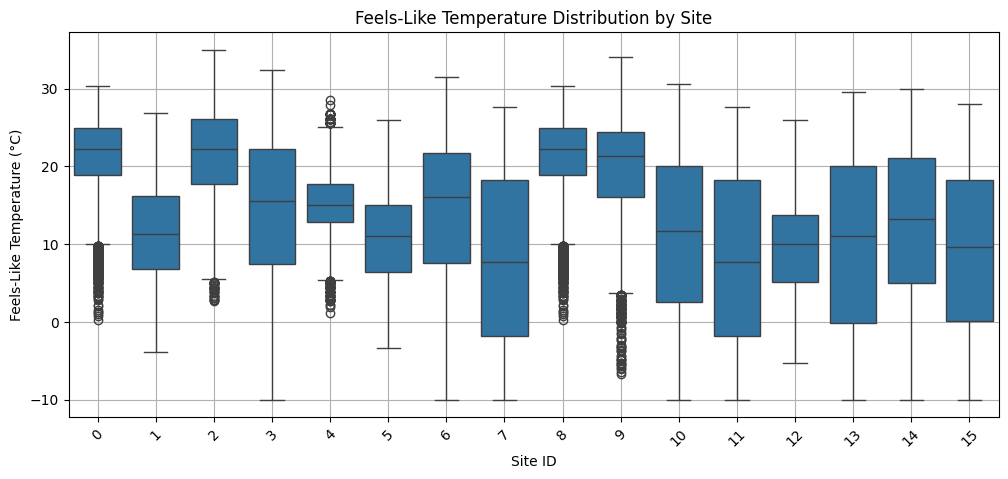

In [55]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=Final_weat, x='site_id', y='feels_like_capped')
plt.xlabel('Site ID')
plt.ylabel('Feels-Like Temperature (°C)')
plt.title('Feels-Like Temperature Distribution by Site')
plt.xticks(rotation=45)
plt.grid()
plt.show()


Handling the building data

In [25]:
buil_cop=building_df.copy()

In [26]:
buil_cop.isna().sum()

site_id           0
building_id       0
primary_use       0
square_feet       0
year_built      774
floor_count    1094
dtype: int64

dropping year built and floor count

In [27]:
buil_cop.drop(columns=['floor_count','year_built'],inplace=True)

Encoding primary type

In [28]:
label_encoder = LabelEncoder()

buil_cop['type_enc'] = label_encoder.fit_transform(buil_cop['primary_use'])



Converting sqaure feet to log values

In [29]:
buil_cop['square_feet_log'] = np.log1p(buil_cop['square_feet'])

dropping handled values

In [30]:
buil_cop.drop(columns=['primary_use','square_feet'],inplace=True)

In [31]:
# buil_cop.shape

Merging train and build data

In [32]:
train_merged = train_df.merge(buil_cop, on="building_id", how="left")

In [33]:
train_merged["timestamp"] = pd.to_datetime(train_merged["timestamp"])

merging the weather data with the train merged

In [34]:
main_merged = train_merged.merge(Final_weat, on=["site_id", "timestamp"], how="inner")

In [35]:
main_merged.shape

(20125605, 26)

In [36]:
main_merged.isna().sum()

building_id           0
meter                 0
timestamp             0
meter_reading         0
site_id               0
type_enc              0
square_feet_log       0
relative_humidity     0
feels_like_capped     0
wind_speed            0
precip_1h_category    0
is_light_rain         0
is_moderate_rain      0
is_heavy_rain         0
hour                  0
day_of_week           0
month                 0
day_of_year           0
is_weekend            0
hour_sin              0
hour_cos              0
day_sin               0
day_cos               0
month_sin             0
month_cos             0
season                0
dtype: int64

In [37]:
main_merged.columns

Index(['building_id', 'meter', 'timestamp', 'meter_reading', 'site_id',
       'type_enc', 'square_feet_log', 'relative_humidity', 'feels_like_capped',
       'wind_speed', 'precip_1h_category', 'is_light_rain', 'is_moderate_rain',
       'is_heavy_rain', 'hour', 'day_of_week', 'month', 'day_of_year',
       'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'season'],
      dtype='object')

In [38]:
main_merged["meter_reading"] = np.log1p(main_merged["meter_reading"])

In [39]:
drop_0readings= list(main_merged[main_merged['meter_reading']==0.0].index)
main_merged.drop(drop_0readings, axis=0, inplace=True)

array([[<Axes: title={'center': 'building_id'}>,
        <Axes: title={'center': 'meter'}>,
        <Axes: title={'center': 'timestamp'}>,
        <Axes: title={'center': 'meter_reading'}>,
        <Axes: title={'center': 'site_id'}>],
       [<Axes: title={'center': 'type_enc'}>,
        <Axes: title={'center': 'square_feet_log'}>,
        <Axes: title={'center': 'relative_humidity'}>,
        <Axes: title={'center': 'feels_like_capped'}>,
        <Axes: title={'center': 'wind_speed'}>],
       [<Axes: title={'center': 'is_light_rain'}>,
        <Axes: title={'center': 'is_moderate_rain'}>,
        <Axes: title={'center': 'is_heavy_rain'}>,
        <Axes: title={'center': 'hour'}>,
        <Axes: title={'center': 'day_of_week'}>],
       [<Axes: title={'center': 'month'}>,
        <Axes: title={'center': 'day_of_year'}>,
        <Axes: title={'center': 'is_weekend'}>,
        <Axes: title={'center': 'hour_sin'}>,
        <Axes: title={'center': 'hour_cos'}>],
       [<Axes: title={'ce

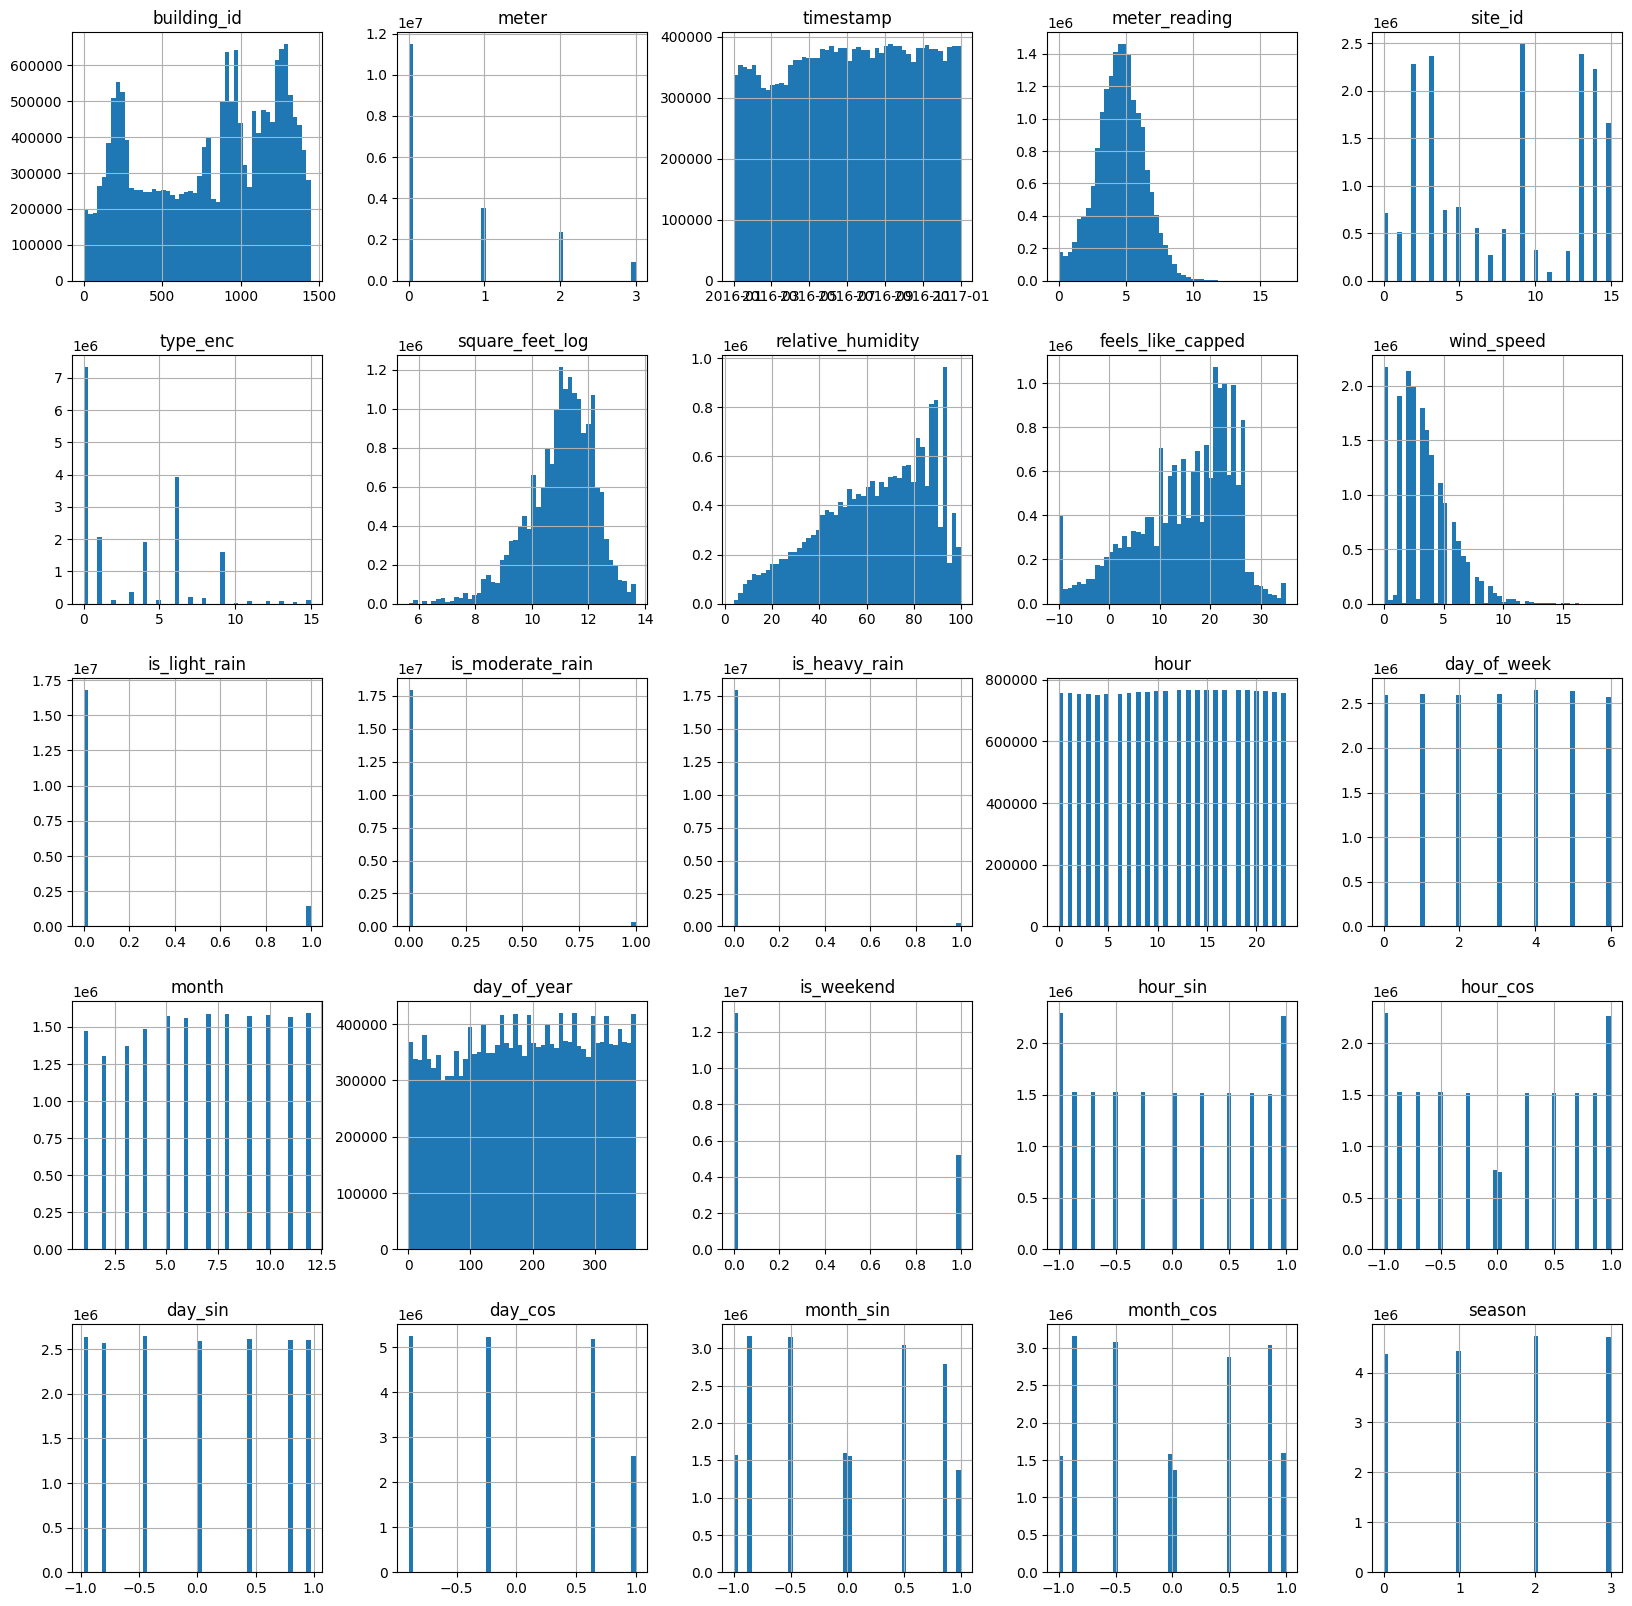

In [40]:
main_merged.hist(bins=50,figsize=(20,20))

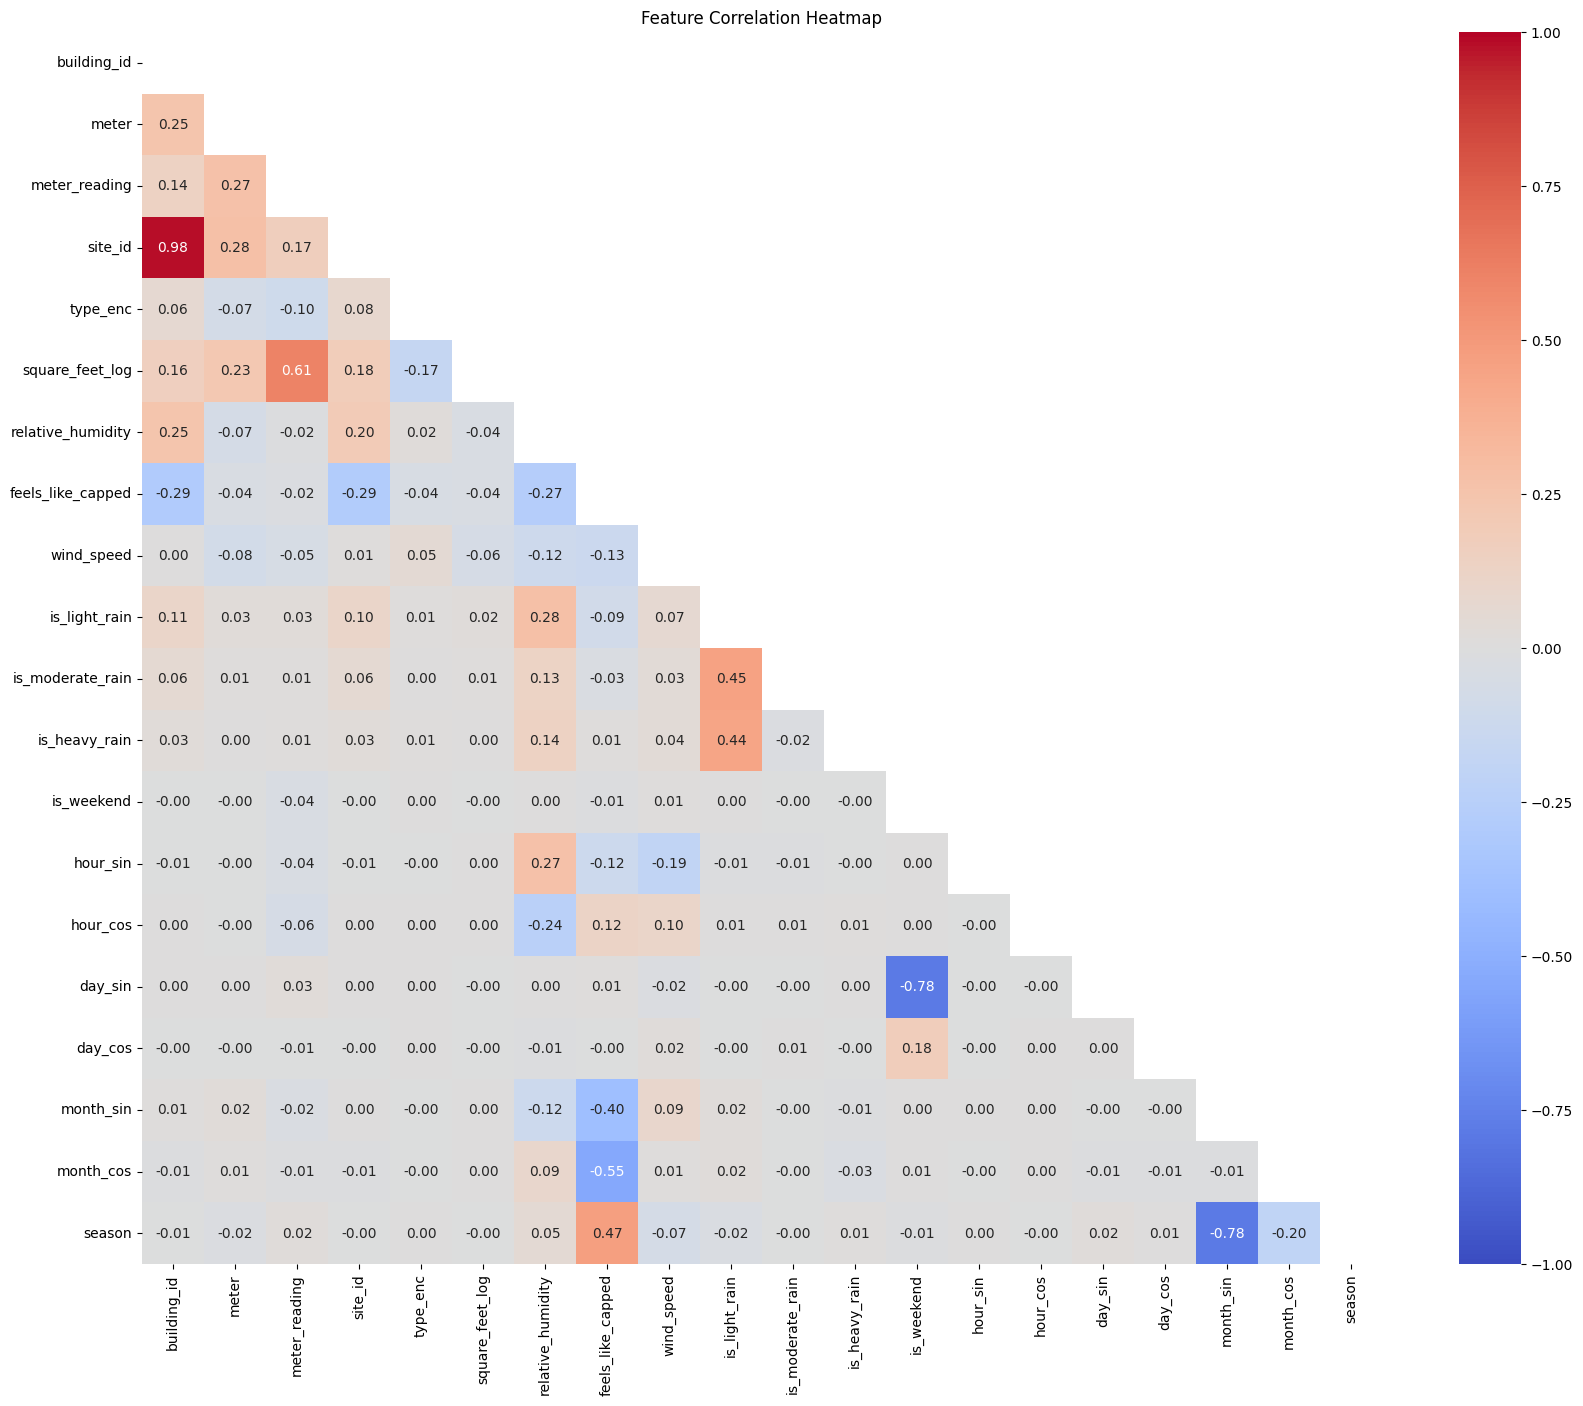

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = main_merged.select_dtypes(include=['float64', 'int64']).columns
corr_df = main_merged[numeric_cols].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    mask=np.triu(np.ones_like(corr_df))  # Hide upper triangle for clarity
)
plt.title("Feature Correlation Heatmap")
plt.show()

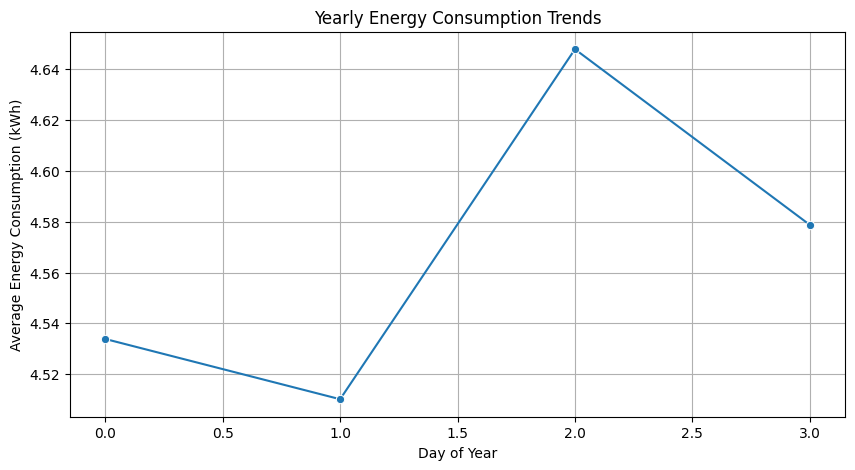

In [85]:
# df_sample = main_merged.sample(n=50000, random_state=42)  # 500K rows only


# plt.figure(figsize=(8, 5))
# sns.scatterplot(data=main_merged, x='feels_like_capped', y='meter_reading', hue='season', alpha=0.7)
# plt.axvline(0, linestyle="--", color="gray")  # Mark zero change line
# plt.xlabel('24-Hour Temperature Change (°C)')
# plt.ylabel('Energy Usage (kWh)')
# plt.title('Effect of Temperature Change on Energy Usage')
# plt.legend(title='Season')
# plt.grid()
# plt.show()


df_daily = main_merged.groupby('season')['meter_reading'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_daily, x='season', y='meter_reading', marker='o')
plt.xlabel('Day of Year')
plt.ylabel('Average Energy Consumption (kWh)')
plt.title('Yearly Energy Consumption Trends')
plt.grid()
plt.show()


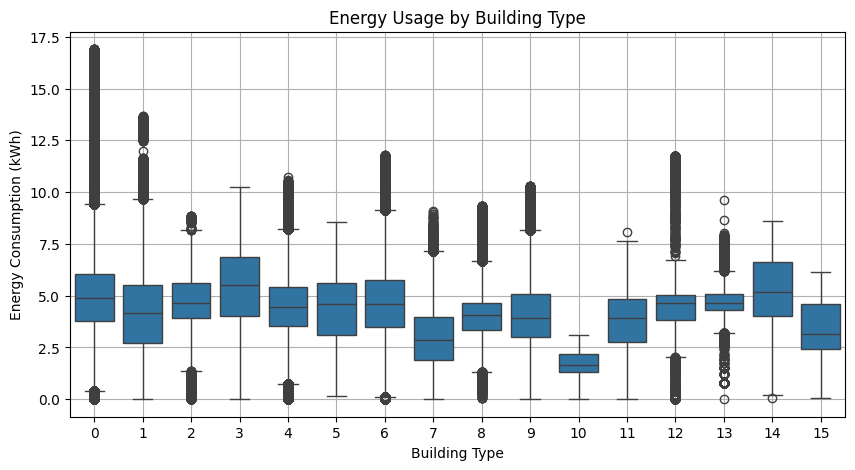

In [68]:
# # # plt.figure(figsize=(12, 5))
# # # sns.lineplot(data=main_merged, x='timestamp', y='meter_reading', hue='meter')
# # # plt.xlabel('Timestamp')
# # # plt.ylabel('Meter Reading (kWh)')
# # # plt.title('Energy Consumption Trends Over Time by Meter Type')
# # # plt.legend(title='Meter Type')
# # # plt.xticks(rotation=45)
# # # plt.grid()
# # # plt.show()
# # plt.figure(figsize=(8, 5))
# # sns.scatterplot(data=main_merged, x='feels_like_capped', y='meter_reading', alpha=0.3)
# # plt.xlabel('Feels-Like Temperature (°C)')
# # plt.ylabel('Energy Usage (kWh)')
# # plt.title('Feels-Like Temperature vs. Energy Consumption')
# # plt.grid()
# # plt.show()
# plt.hexbin(main_merged['feels_like_capped'], main_merged['meter_reading'], gridsize=50, cmap='coolwarm')
# plt.colorbar(label='Density')
# plt.xlabel('Feels-Like Temperature (°C)')
# plt.ylabel('Energy Usage (kWh)')
# plt.title('Hexbin Plot: Feels-Like vs Energy Consumption')
# plt.show()
plt.figure(figsize=(10, 5))
sns.boxplot(data=main_merged, x='type_enc', y='meter_reading')
plt.xlabel('Building Type')
plt.ylabel('Energy Consumption (kWh)')
plt.title('Energy Usage by Building Type')
plt.grid()
plt.show()


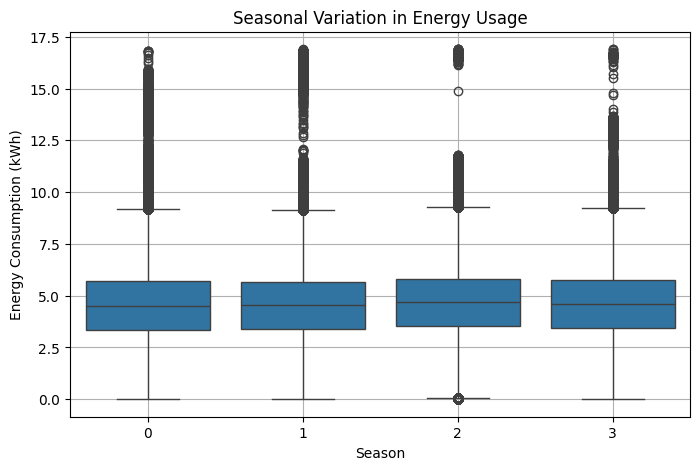

In [71]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=main_merged, x='season', y='meter_reading')
plt.xlabel('Season')
plt.ylabel('Energy Consumption (kWh)')
plt.title('Seasonal Variation in Energy Usage')
plt.grid()
plt.show()


In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting only numerical columns
num_cols = main_merged.select_dtypes(include=['number']).columns
# num_cols = ['meter', 'meter_reading', 'site_id', 'type_enc',
#        'square_feet_log', 'relative_humidity', 'feels_like_capped',
#        'wind_speed', 'is_light_rain', 'is_moderate_rain', 'is_heavy_rain',
#        'hour', 'day_of_week', 'month', 'is_weekend', 'hour_sin',
#        'hour_cos', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'season']
# Setting up the plot layout
# plt.figure(figsize=(15, 10))
# main_merged[num_cols].boxplot(rot=90)  # Rotating labels for better readability
# plt.title("Boxplots of Numerical Features")
# plt.xticks(rotation=45)
# plt.show()


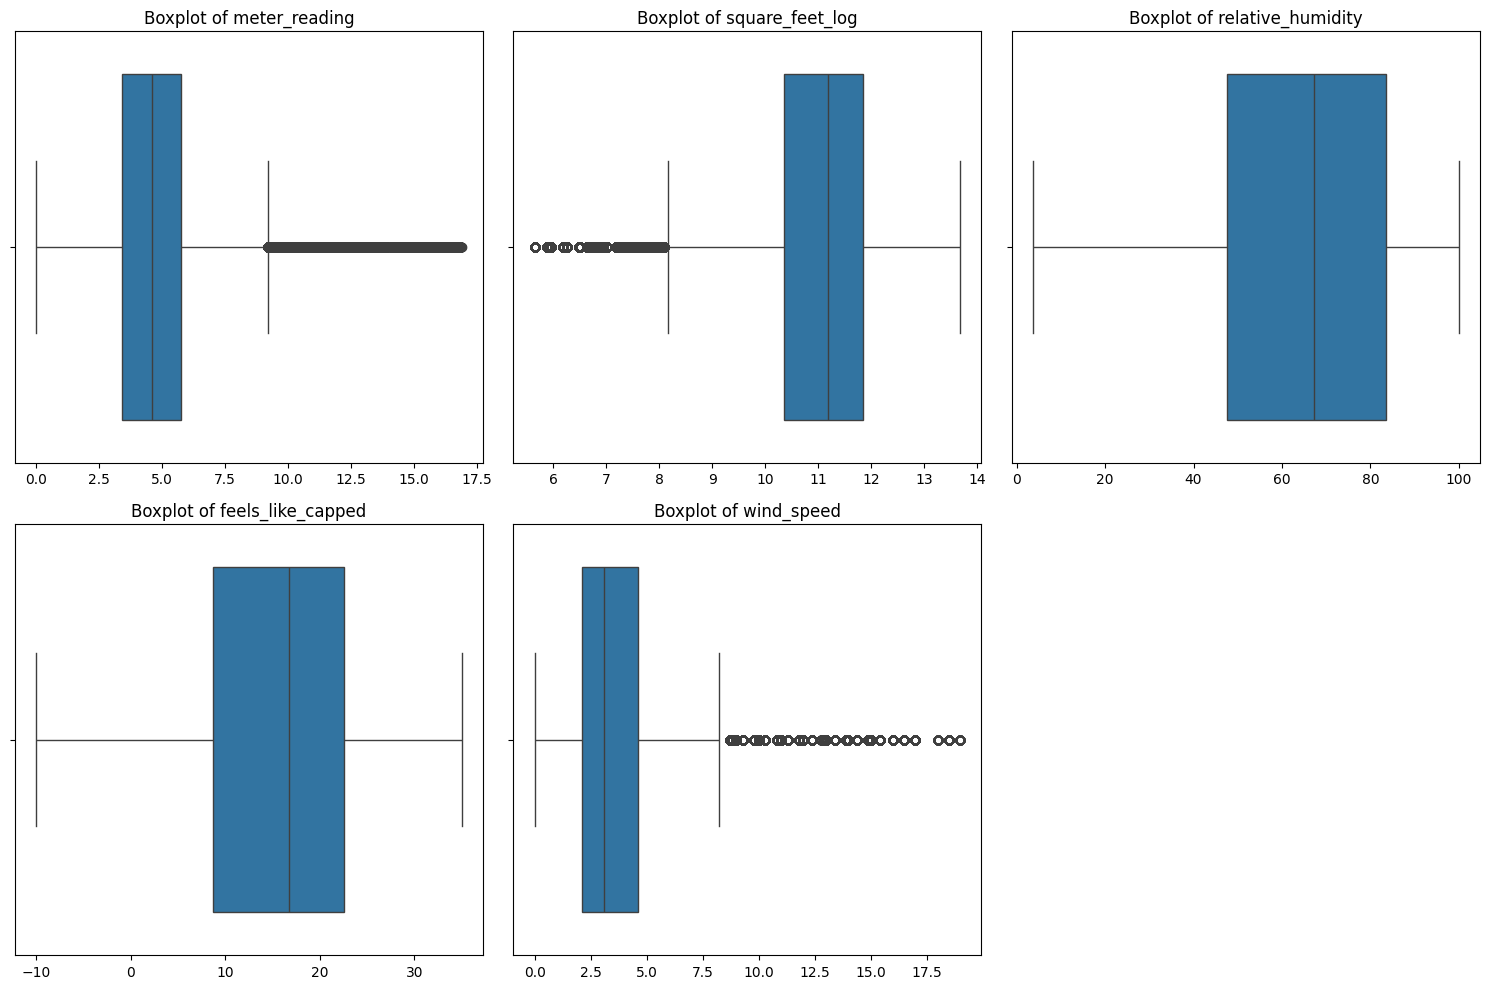

In [82]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Selecting only numerical columns
# num_cols = main_merged.select_dtypes(include=['number']).columns

num_cols = ['meter_reading','square_feet_log', 'relative_humidity', 'feels_like_capped',
       'wind_speed']

# Define the number of rows and columns for subplots
n_cols = 3  # Number of columns in subplot
n_rows = int(np.ceil(len(num_cols) / n_cols))  # Calculate rows dynamically

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # Flatten to make indexing easier

# Plot each numerical column
for i, col in enumerate(num_cols):
    sns.boxplot(data=main_merged, x=col, ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_xlabel('')  # Remove x-label for clarity

# Hide unused subplots (if any)
for i in range(len(num_cols), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()  # Adjust layout to prevent overlapping
plt.show()


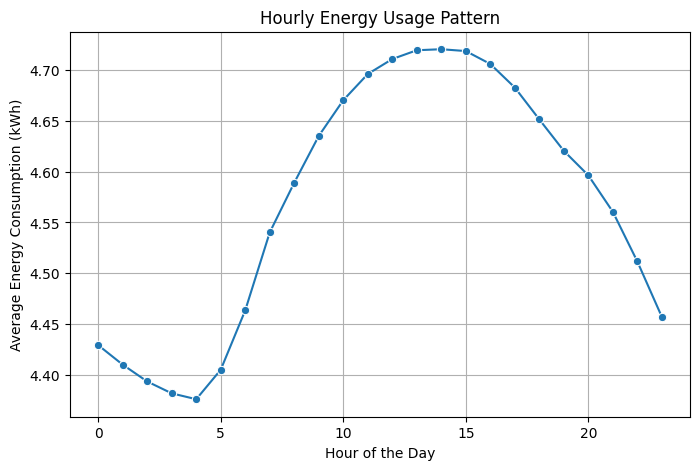

In [74]:
# # plt.figure(figsize=(6,6))
# # sns.scatterplot(data=main_merged, x='hour_sin', y='hour_cos', alpha=0.5)
# # plt.xlabel('Hour Sine Encoding')
# # plt.ylabel('Hour Cosine Encoding')
# # plt.title('Cyclical Encoding: Hour_sin vs Hour_cos')
# # plt.grid()
# # plt.show()
# plt.figure(figsize=(8, 5))
# sns.scatterplot(data=main_merged, x='wind_speed', y='meter_reading', alpha=0.3)
# plt.xlabel('Wind Speed (m/s)')
# plt.ylabel('Energy Consumption (kWh)')
# plt.title('Wind Speed vs. Energy Consumption')
# plt.grid()
# plt.show()
df_hourly = main_merged.groupby('hour')['meter_reading'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(data=df_hourly, x='hour', y='meter_reading', marker='o')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Energy Consumption (kWh)')
plt.title('Hourly Energy Usage Pattern')
plt.grid()
plt.show()


In [100]:
features=['building_id', 'meter', 'site_id',
       'type_enc', 'square_feet_log', 'relative_humidity', 'feels_like_capped',
       'wind_speed', 'is_light_rain', 'is_moderate_rain',
       'is_heavy_rain', 'hour', 'day_of_week', 'month', 'day_of_year',
       'is_weekend', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'month_sin',
       'month_cos', 'season']
target = "meter_reading"

X = main_merged[features]
y = main_merged[target]

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)



In [86]:
def rmsle_lgbm(y_pred, data):

    y_true = np.array(data.get_label())
    score = np.sqrt(np.mean(np.power(np.log1p(y_true) - np.log1p(y_pred), 2)))

    return 'rmsle', score, False


In [87]:
# params = {
#     "objective": "regression",
#     "metric": "rmse",
#     "boosting_type": "gbdt",
#     "learning_rate": 0.05,
#     "num_leaves": 31,
#     "max_depth": -1,
#     "subsample": 0.8,
#     "colsample_bytree": 0.8,
#     "n_estimators": 1000,
#     "verbose": -1
# }

# # Convert to LightGBM dataset
# train_data = lgb.Dataset(X_train, label=y_train)
# val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# # Train the model
# # model = lgb.train(params, train_data, valid_sets=[val_data], early_stopping_rounds=50, verbose_eval=100)
# model = lgb.train(
#     params,
#     train_data,
#     valid_sets=[val_data],
#     callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)]
# )


params = {
    "objective": "regression",
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": -1,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "n_estimators": 1000,
    "verbose": -1
}

# Convert to LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# Train the model
# model = lgb.train(params, train_data, valid_sets=[val_data], early_stopping_rounds=50, verbose_eval=100)
model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(100)],
    feval=rmsle_lgbm
)


Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 0.908103	valid_0's rmsle: 0.235598
[200]	valid_0's l2: 0.738594	valid_0's rmsle: 0.215393
[300]	valid_0's l2: 0.652309	valid_0's rmsle: 0.203572
[400]	valid_0's l2: 0.588231	valid_0's rmsle: 0.194159
[500]	valid_0's l2: 0.542552	valid_0's rmsle: 0.186785
[600]	valid_0's l2: 0.507487	valid_0's rmsle: 0.181531
[700]	valid_0's l2: 0.473906	valid_0's rmsle: 0.175746
[800]	valid_0's l2: 0.445796	valid_0's rmsle: 0.171352
[900]	valid_0's l2: 0.423838	valid_0's rmsle: 0.167321
[1000]	valid_0's l2: 0.401316	valid_0's rmsle: 0.163011
Did not meet early stopping. Best iteration is:
[1000]	valid_0's l2: 0.401316	valid_0's rmsle: 0.163011


In [74]:
from sklearn.metrics import r2_score
y_train_pred = model.predict(X_train)

# Calculate R² Score
r2 = r2_score(y_train, y_train_pred)
print("Training R² Score:", r2)
y_test_pred = model.predict(X_val)

# Calculate R² Score
r2_test = r2_score(y_val, y_test_pred)
print("Test R² Score:", r2_test)

Training R² Score: 0.872683484233842
Test R² Score: 0.8721762107800557


In [90]:
main_merged.head()

,building_id,meter,timestamp,meter_reading,site_id,type_enc,square_feet_log,relative_humidity,feels_like_capped,wind_speed,...,month,day_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season
45,46,0,2016-01-01,3.993413,0,11,9.110078,73.780558,25.000000,0.0,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
72,74,0,2016-01-01,3.784219,0,8,12.867830,73.780558,25.000000,0.0,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
91,93,0,2016-01-01,3.978196,0,6,10.415443,73.780558,25.000000,0.0,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
103,105,0,2016-01-01,3.190624,1,0,10.832181,90.569196,3.661084,3.1,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0
104,106,0,2016-01-01,0.318163,1,0,8.589514,90.569196,3.661084,3.1,...,1,1,0,0.0,1.0,-0.433884,-0.900969,0.5,0.866025,0


In [1]:
# from sklearn.model_selection import train_test_split, cross_val_score
# import xgboost as xgb
# from sklearn.metrics import mean_squared_error

# X = main_merged[features]
# y = main_merged[target]

# # Split data into training and testing sets (80% train, 20% test)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Define the XGBoost regressor with optimized parameters
# xgb_model = xgb.XGBRegressor(
#     objective='reg:squarederror',  
#     learning_rate=0.05,  
#     n_estimators=1000,  
#     max_depth=6,  
#     subsample=0.8,  
#     colsample_bytree=0.8,  
#     gamma=0.1,  
#     reg_alpha=0.1,  
#     reg_lambda=0.5,  
#     random_state=42
# )

# # Train the model
# xgb_model.fit(
#     X_train, y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=False
# )

# # Predict on test set
# y_pred = xgb_model.predict(X_test)

In [96]:
main_merged.dtypes

building_id                    int64
meter                          int64
timestamp             datetime64[ns]
meter_reading                float64
site_id                        int64
type_enc                       int64
square_feet_log              float64
relative_humidity            float64
feels_like_capped            float64
wind_speed                   float64
precip_1h_category          category
is_light_rain                  int64
is_moderate_rain               int64
is_heavy_rain                  int64
hour                           int32
day_of_week                    int32
month                          int32
day_of_year                    int32
is_weekend                     int64
hour_sin                     float64
hour_cos                     float64
day_sin                      float64
day_cos                      float64
month_sin                    float64
month_cos                    float64
season                         int64
dtype: object

In [98]:
main_merged.drop(columns=['precip_1h_category'],inplace=True)

,building_id,meter,timestamp,meter_reading,site_id,type_enc,square_feet_log,relative_humidity,feels_like_capped,wind_speed,...,month,day_of_year,is_weekend,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos,season
45,46,0,2016-01-01 00:00:00,3.993413,0,11,9.110078,73.780558,25.000000,0.0,...,1,1,0,0.000000,1.000000,-0.433884,-0.900969,5.000000e-01,0.866025,0
72,74,0,2016-01-01 00:00:00,3.784219,0,8,12.867830,73.780558,25.000000,0.0,...,1,1,0,0.000000,1.000000,-0.433884,-0.900969,5.000000e-01,0.866025,0
91,93,0,2016-01-01 00:00:00,3.978196,0,6,10.415443,73.780558,25.000000,0.0,...,1,1,0,0.000000,1.000000,-0.433884,-0.900969,5.000000e-01,0.866025,0
103,105,0,2016-01-01 00:00:00,3.190624,1,0,10.832181,90.569196,3.661084,3.1,...,1,1,0,0.000000,1.000000,-0.433884,-0.900969,5.000000e-01,0.866025,0
104,106,0,2016-01-01 00:00:00,0.318163,1,0,8.589514,90.569196,3.661084,3.1,...,1,1,0,0.000000,1.000000,-0.433884,-0.900969,5.000000e-01,0.866025,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20125599,1443,0,2016-12-31 23:00:00,4.188897,15,0,10.604404,58.365360,-0.970798,8.8,...,12,366,1,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,0
20125600,1444,0,2016-12-31 23:00:00,2.277267,15,1,9.884305,58.365360,-0.970798,8.8,...,12,366,1,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,0
20125601,1445,0,2016-12-31 23:00:00,1.762159,15,0,8.366138,58.365360,-0.970798,8.8,...,12,366,1,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,0
20125603,1447,0,2016-12-31 23:00:00,5.078761,15,4,10.301458,58.365360,-0.970798,8.8,...,12,366,1,-0.258819,0.965926,-0.974928,-0.222521,-2.449294e-16,1.000000,0
